Machine Failure Detection System

In [4]:
#too much NaN data at the "wo_type" column, so I have to delete it

import pandas as pd
import numpy as np

df = pd.read_csv('allData.csv')

df = df.drop(columns = 'wo_type')

In [5]:
# now, we have to filter the data by leaving only the time where temp of motor >
# 80C, and load > 85%

stressed_motors = df[(df["temp_motor_degC"] > 80) & (df["load_pct"] > 85) ]

In [6]:
df["vibration_h_rolling_std"] = df["vibration_h_mms"].rolling(window=7).std()

In [7]:
#breakdowns during high stress

print(f"Breakdowns during high stress: {stressed_motors["breakdown_flag"].value_counts(normalize=True)*100}")


#failure percentage throuought the whole data set

print(f"Failure percentage: {df["breakdown_flag"].value_counts(normalize=True)*100}")

Breakdowns during high stress: breakdown_flag
0    86.617647
1    13.382353
Name: proportion, dtype: float64
Failure percentage: breakdown_flag
0    90.120548
1     9.879452
Name: proportion, dtype: float64


<function matplotlib.pyplot.show(close=None, block=None)>

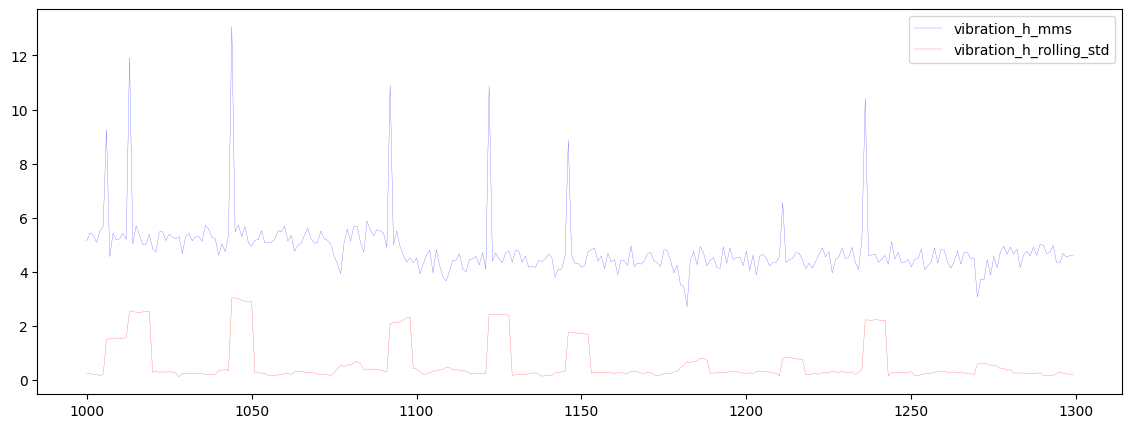

In [8]:
import matplotlib.pyplot as plt

zoom_df = df.iloc[1000:1300]

zoom_df[["vibration_h_mms", "vibration_h_rolling_std"]].plot(
figsize=(14,5),
color = ['blue', 'red'],
alpha = 0.7,
linewidth = 0.2
)

plt.show


now, imma do the training steps

In [10]:
from sklearn.model_selection import train_test_split

# Imma drop non-sensor columns
X = df.drop(columns=['transaction_date', 'asset_tag', 'machine_type',
                     'plant_code', 'part_no', 'part_description',
                     'part_family', 'criticality', 'uom', 'breakdown_flag'])

y = df['breakdown_flag'] # what we want to predict


X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


print(f"Training features shape: {X_train.shape}")
print(f"Testing features shape: {X_test.shape}")

Training features shape: (175200, 12)
Testing features shape: (43800, 12)


Starting the training
Model is successfully trained

--- CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

           0       0.91      0.95      0.93     39473
           1       0.17      0.10      0.13      4327

    accuracy                           0.86     43800
   macro avg       0.54      0.52      0.53     43800
weighted avg       0.83      0.86      0.85     43800



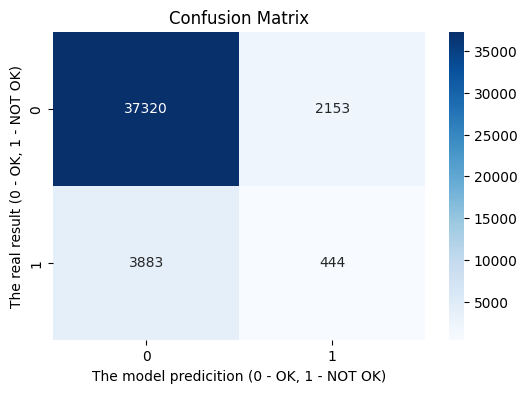

In [12]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 100 decision trees
model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

print("Starting the training")
model.fit(X_train, y_train)
print("Model is successfully trained\n")

predictions = model.predict(X_test)

print("--- CLASSIFICATION REPORT ---")
print(classification_report(y_test, predictions))

#Confusion Matrix
cm = confusion_matrix(y_test, predictions)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('The model predicition (0 - OK, 1 - NOT OK)')
plt.ylabel('The real result (0 - OK, 1 - NOT OK)')
plt.show()